# Baselines (paper models) vs symbolic student — comparison

Reads parquet files off disk and overlays residuals, pulls, and an I68 resolution table.
Everything is driven by the `FILES` list in the config cell — add/remove/comment entries there.

**Per-file scaling.** Paper baselines use the paper normalization; symbolic runs use their own
tfrecord `labels_scale` (auto-read from `labels_scale.json` next to each parquet). One global
scale would distort the overlay, so each file carries its own.

**Auto kind detection.** SLIM files (no cotA, no sigmas) are automatically skipped on the α panel
and on the pull plots.

**Fairness note for the writeup.** Baseline parquets were evaluated on the paper test set; the
symbolic runs on the centeredIncidence split. Resolution (I68) comparison is fair; bin-by-bin
*bias* overlays cross datasets, and Jennet's origin-offset point applies — read residual *shape*,
not absolute offset, across the two families.

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings("ignore")
pi = np.pi

In [2]:
#==============================================================================
# CONFIGURATION -- edit FILES, then Run All
#==============================================================================
BASE = "/depot/cms/private/users/kuang14/Smart_Pixel/smart-pixels-digitization/baseline_models"
SYM  = "/depot/cms/private/users/kuang14/Smart_Pixel"

# paper-pipeline normalization (applies to every baseline parquet)
PAPER_SCALE = (122.89689703635774, 30.903849401109394,
               6.560914919886437,  1.917222249583349)
# fallback for symbolic parquets if no labels_scale.json sits next to them
MOE_SCALE = None    # e.g. (75.0, 18.75, 6.577, 1.930)

def auto_scale(path):
    js = os.path.join(os.path.dirname(path), "labels_scale.json")
    if os.path.exists(js):
        return tuple(json.load(open(js))["labels_scale"])
    assert MOE_SCALE is not None, f"no labels_scale.json near {path} and MOE_SCALE unset"
    return MOE_SCALE

# scale="paper" -> PAPER_SCALE ; scale="auto" -> read labels_scale.json next to the parquet
FILES = [
    # ---- paper baselines (20t = information parity with the symbolic student) ----
    dict(path=f"{BASE}/20t-conv2d_MAX-vars.parquet",  label="Conv2D MAX (20t)",  color="black",      scale="paper"),
    dict(path=f"{BASE}/20t-conv2d_FULL-vars.parquet", label="Conv2D Full (20t)", color="dimgray",    scale="paper"),
    dict(path=f"{BASE}/20t-conv1d_FULL-vars.parquet", label="Conv1D Full (20t)", color="tab:blue",   scale="paper"),
    dict(path=f"{BASE}/20t-mlp_FULL-vars.parquet",    label="MLP Full (20t)",    color="tab:orange", scale="paper"),
    # ---- symbolic students (calibrated) ----
    # pre-axisfix (ansatz v2 + AxisFixExpert), kept as the "before" reference
    dict(path=f"{SYM}/symbolic_ablation_nexp1/symbolic_n1_vars.parquet", label="Symbolic 1 formula (pre-axisfix)", color="thistle", scale="auto"),
    dict(path=f"{SYM}/symbolic_axisfix_nexp1/symbolic_n1_vars.parquet", label="Symbolic 1 formula", color="tab:purple", scale="auto"),
    # dict(path=f"{SYM}/symbolic_ablation_nexp2/symbolic_n2_vars.parquet", label="Symbolic MoE 2-exp", color="magenta",    scale="auto"),
    dict(path=f"{SYM}/symbolic_ablation_nexp4/symbolic_n4_vars.parquet", label="Symbolic MoE 4-exp (pre-axisfix)", color="palegreen", scale="auto"),
    dict(path=f"{SYM}/symbolic_axisfix_nexp4/symbolic_n4_vars.parquet", label="Symbolic MoE 4-exp", color="tab:green",  scale="auto"),
    # ---- input digitization, PUBLISHED thresholds (248/668/1663 e-, arXiv:2602.15946
    #      Fig. 3) with code levels 0..3 = paper Eq. 1. This is the comparable set.
    dict(path=f"{SYM}/digi_analog_nexp1/symbolic_n1_vars.parquet",            label="Sym 1-formula, analog",      color="tab:purple",  scale="auto"),
    dict(path=f"{SYM}/digi_4bit_lowfirst_code_nexp1/symbolic_n1_vars.parquet", label="Sym 1-formula, 4-bit",       color="lightsalmon", scale="auto"),
    dict(path=f"{SYM}/digi_3bit_lowfirst_code_nexp1/symbolic_n1_vars.parquet", label="Sym 1-formula, 3-bit",       color="darkorange",  scale="auto"),
    dict(path=f"{SYM}/digi_2bit_paper_code_nexp1/symbolic_n1_vars.parquet",    label="Sym 1-formula, 2-bit paper", color="tab:red",     scale="auto"),
    # LUT cost: same published thresholds, midpoint levels instead of the bin index
    dict(path=f"{SYM}/digi_2bit_paper_midpoint_nexp1/symbolic_n1_vars.parquet", label="Sym 1-formula, 2-bit +LUT", color="salmon",     scale="auto"),
    # trainable thresholds (paper Sec. IV), initialised from the published set
    dict(path=f"{SYM}/digi_2bit_paper_code_trainthr_nexp1/symbolic_n1_vars.parquet", label="Sym 1-formula, 2-bit learned-T", color="darkred", scale="auto"),
    # ---- noise arms (train_noise_ablation.ipynb). Published thresholds + Eq. 6 noise
    #      on the analog charge. 80 e- = sigma_noise = nominal.
    dict(path=f"{SYM}/digi_2bit_paper_code_noise80_nexp1/symbolic_n1_vars.parquet", label="Sym 1-formula, 2-bit + 80e- noise", color="crimson", scale="auto"),
    dict(path=f"{SYM}/digi_2bit_paper_code_noise40_nexp1/symbolic_n1_vars.parquet", label="Sym 1-formula, 2-bit + 40e- noise", color="lightcoral", scale="auto"),
    dict(path=f"{SYM}/digi_2bit_paper_code_noise160_nexp1/symbolic_n1_vars.parquet", label="Sym 1-formula, 2-bit + 160e- noise", color="maroon", scale="auto"),
    # ---- SUPERSEDED: occupancy-derived thresholds (100/240/1295 e-), T0 at 1.25
    #      sigma_noise. Not comparable to the paper. Kept only as the "before".
    # dict(path=f"{SYM}/digi_2bit_lowfirst_midpoint_nexp1/symbolic_n1_vars.parquet", label="Sym 1-formula, 2-bit (old thr)", color="gray", scale="auto"),
    # ---- 2t baselines: hardware-parity claim (keep as a SEPARATE plot, not mixed with 20t) ----
    # dict(path=f"{BASE}/2t-mlp_FULL-vars.parquet",     label="MLP Full (2t)",     color="tab:red",  scale="paper"),
]

# per-model parameter counts for the params-vs-resolution scatter (fill symbolic from summary.json)
PARAM_COUNTS = {
    "Conv2D MAX (20t)":  1898,
    "Conv2D Full (20t)": 1767,
    "Conv1D Full (20t)": 2734,
    "MLP Full (20t)":    2264,
    # "Symbolic 1 formula": 370,
    # "Symbolic MoE 4-exp": 3260,
}

SHOW_BANDS = False        # sigma bands on residual panels (busy with many files)
figsize_residuals = (16, 11)
figsize_pulls     = (16, 11)
output_dir = None         # e.g. "./plots" to save PNGs/CSV, or None
save_dpi   = 300

In [3]:
#==============================================================================
# LOAD + auto-detect kind + resolve per-file scale
#==============================================================================
entries = []
for f in FILES:
    if not os.path.exists(f["path"]):
        print("MISSING (skipped):", f["path"]); continue
    df = pd.read_parquet(f["path"])
    cols = set(df.columns)
    has_alpha = "cotA" in cols and "cotAtrue" in cols
    has_sigma = "sigmax" in cols
    scale = PAPER_SCALE if f["scale"] == "paper" else auto_scale(f["path"])
    entries.append(dict(df=df, label=f["label"], color=f["color"],
                        scale=np.asarray(scale, float),
                        has_alpha=has_alpha, has_sigma=has_sigma))
    kind = ("FULL/MAX" if has_alpha else "SLIM") + ("+sigma" if has_sigma else "")
    print(f"[{f['label']:<22s}] {len(df):>7d} rows | {kind:12s} | "
          f"scale=({scale[0]:.2f}, {scale[1]:.2f}, {scale[2]:.4f}, {scale[3]:.4f})")

assert entries, "nothing loaded -- check paths in FILES"
print(f"\n{len(entries)} files loaded.")

[Conv2D MAX (20t)      ]  108222 rows | FULL/MAX+sigma | scale=(122.90, 30.90, 6.5609, 1.9172)
[Conv2D Full (20t)     ]  108222 rows | FULL/MAX+sigma | scale=(122.90, 30.90, 6.5609, 1.9172)
[Conv1D Full (20t)     ]  108222 rows | FULL/MAX+sigma | scale=(122.90, 30.90, 6.5609, 1.9172)
[MLP Full (20t)        ]  108222 rows | FULL/MAX+sigma | scale=(122.90, 30.90, 6.5609, 1.9172)
[Symbolic 1 formula (pre-axisfix)]  108222 rows | FULL/MAX+sigma | scale=(123.41, 30.93, 6.5775, 1.9296)
[Symbolic 1 formula    ]  108222 rows | FULL/MAX+sigma | scale=(123.41, 30.93, 6.5775, 1.9296)
[Symbolic MoE 4-exp (pre-axisfix)]  108222 rows | FULL/MAX+sigma | scale=(123.41, 30.93, 6.5775, 1.9296)
[Symbolic MoE 4-exp    ]  108222 rows | FULL/MAX+sigma | scale=(123.41, 30.93, 6.5775, 1.9296)
MISSING (skipped): /depot/cms/private/users/kuang14/Smart_Pixel/digi_analog_nexp1/symbolic_n1_vars.parquet
MISSING (skipped): /depot/cms/private/users/kuang14/Smart_Pixel/digi_4bit_lowfirst_code_nexp1/symbolic_n1_vars.pa

In [4]:
#==============================================================================
# HELPERS
#==============================================================================
def inverse_cot(c):
    return np.arctan2(1.0, np.asarray(c, float))     # stable, range (0, pi)

def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

def i68(r):
    """paper resolution metric: half-width of the minimal interval containing 68% of residuals"""
    r = np.sort(np.asarray(r)[np.isfinite(r)])
    n = len(r); k = int(np.ceil(0.68 * n))
    if k >= n: return (r[-1] - r[0]) / 2.0
    return (r[k:] - r[:n - k]).min() / 2.0

def get_phys(e, var):
    """(true, pred, sigma_or_None) in physical units; angles in DEGREES."""
    sx, sy, sa, sb = e["scale"]
    s = {"x": sx, "y": sy, "cotA": sa, "cotB": sb}[var]
    df = e["df"]
    if var in ("x", "y"):
        t, p = df[var + "true"].values * s, df[var].values * s
        sig = df["sigma" + var].values * s if e["has_sigma"] else None
        return t, p, sig
    t = np.degrees(inverse_cot(df[var + "true"].values * s))
    p = np.degrees(inverse_cot(df[var].values * s))
    sig = None
    if e["has_sigma"]:
        pu  = np.degrees(inverse_cot((df[var].values + df["sigma" + var].values) * s))
        pd_ = np.degrees(inverse_cot((df[var].values - df["sigma" + var].values) * s))
        sig = 0.5 * (np.abs(pu - p) + np.abs(pd_ - p))
    return t, p, sig

def residual_scatter(ax, t, p, color, label, nbins=50, sigma=None, band=False, alpha=0.18):
    res = t - p
    xmin, xmax = np.min(t), np.max(t)
    sns.regplot(x=t, y=res, x_bins=np.linspace(xmin, xmax, nbins),
                fit_reg=None, marker=".", ax=ax, color=color, label=label)
    if band and sigma is not None:
        step = (xmax - xmin) / nbins; ctrs = np.linspace(xmin, xmax, nbins)
        up, dn = [], []
        for i in range(nbins):
            m = (t > xmin + i*step) & (t < xmin + (i+1)*step)
            mu = res[m].mean() if m.sum() else np.nan
            sg = sigma[m].mean() if m.sum() else np.nan
            up.append(mu + sg); dn.append(mu - sg)
        ax.fill_between(ctrs, dn, up, alpha=alpha, color=color)

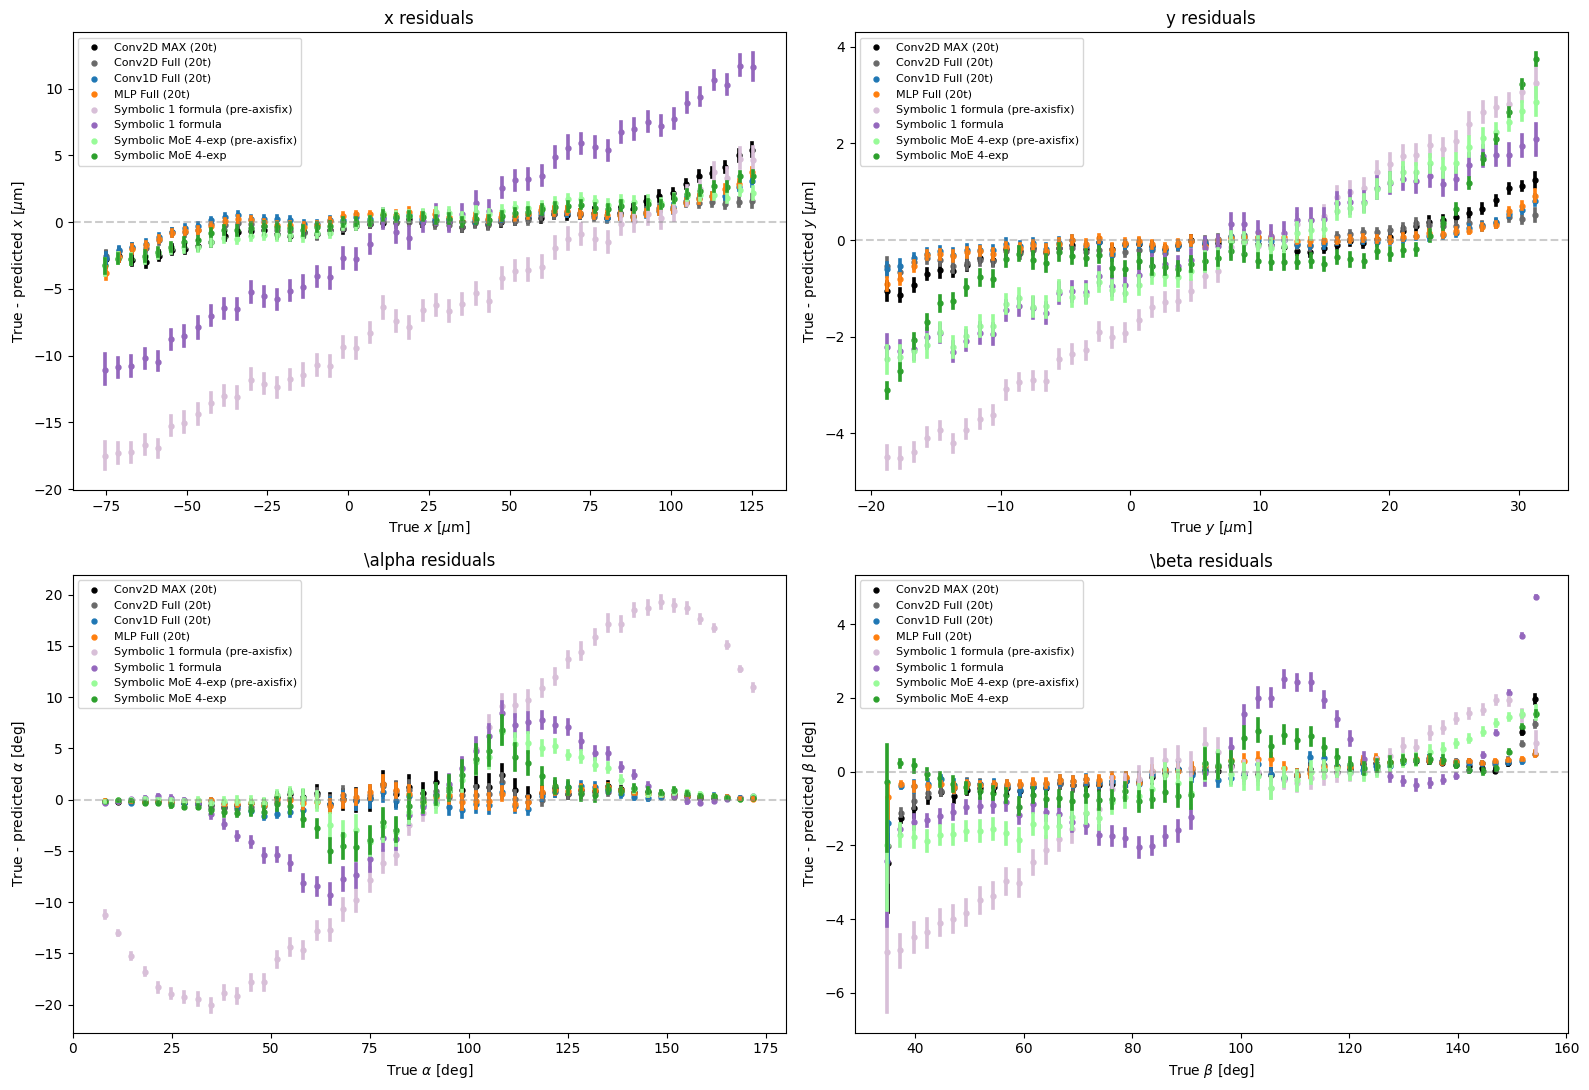

In [5]:
#==============================================================================
# RESIDUALS (2x2: x, y, alpha, beta) -- SLIM files auto-skip alpha
#==============================================================================
fig, axes = plt.subplots(2, 2, figsize=figsize_residuals)
panels = [("x", r"$x$ [$\mu$m]", axes[0, 0]), ("y", r"$y$ [$\mu$m]", axes[0, 1]),
          ("cotA", r"$\alpha$ [deg]", axes[1, 0]), ("cotB", r"$\beta$ [deg]", axes[1, 1])]
for var, name, ax in panels:
    for e in entries:
        if var == "cotA" and not e["has_alpha"]:
            continue
        t, p, sig = get_phys(e, var)
        residual_scatter(ax, t, p, e["color"], e["label"], sigma=sig, band=SHOW_BANDS)
    ax.axhline(0, alpha=0.4, ls="dashed", color="gray")
    ax.set_xlabel("True " + name); ax.set_ylabel("True - predicted " + name)
    ax.set_title(name.split(" ")[0].replace("$", "") + " residuals")
    ax.legend(fontsize=8)
plt.tight_layout()
if output_dir:
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, "residuals.png"), dpi=save_dpi, bbox_inches="tight")
plt.show()

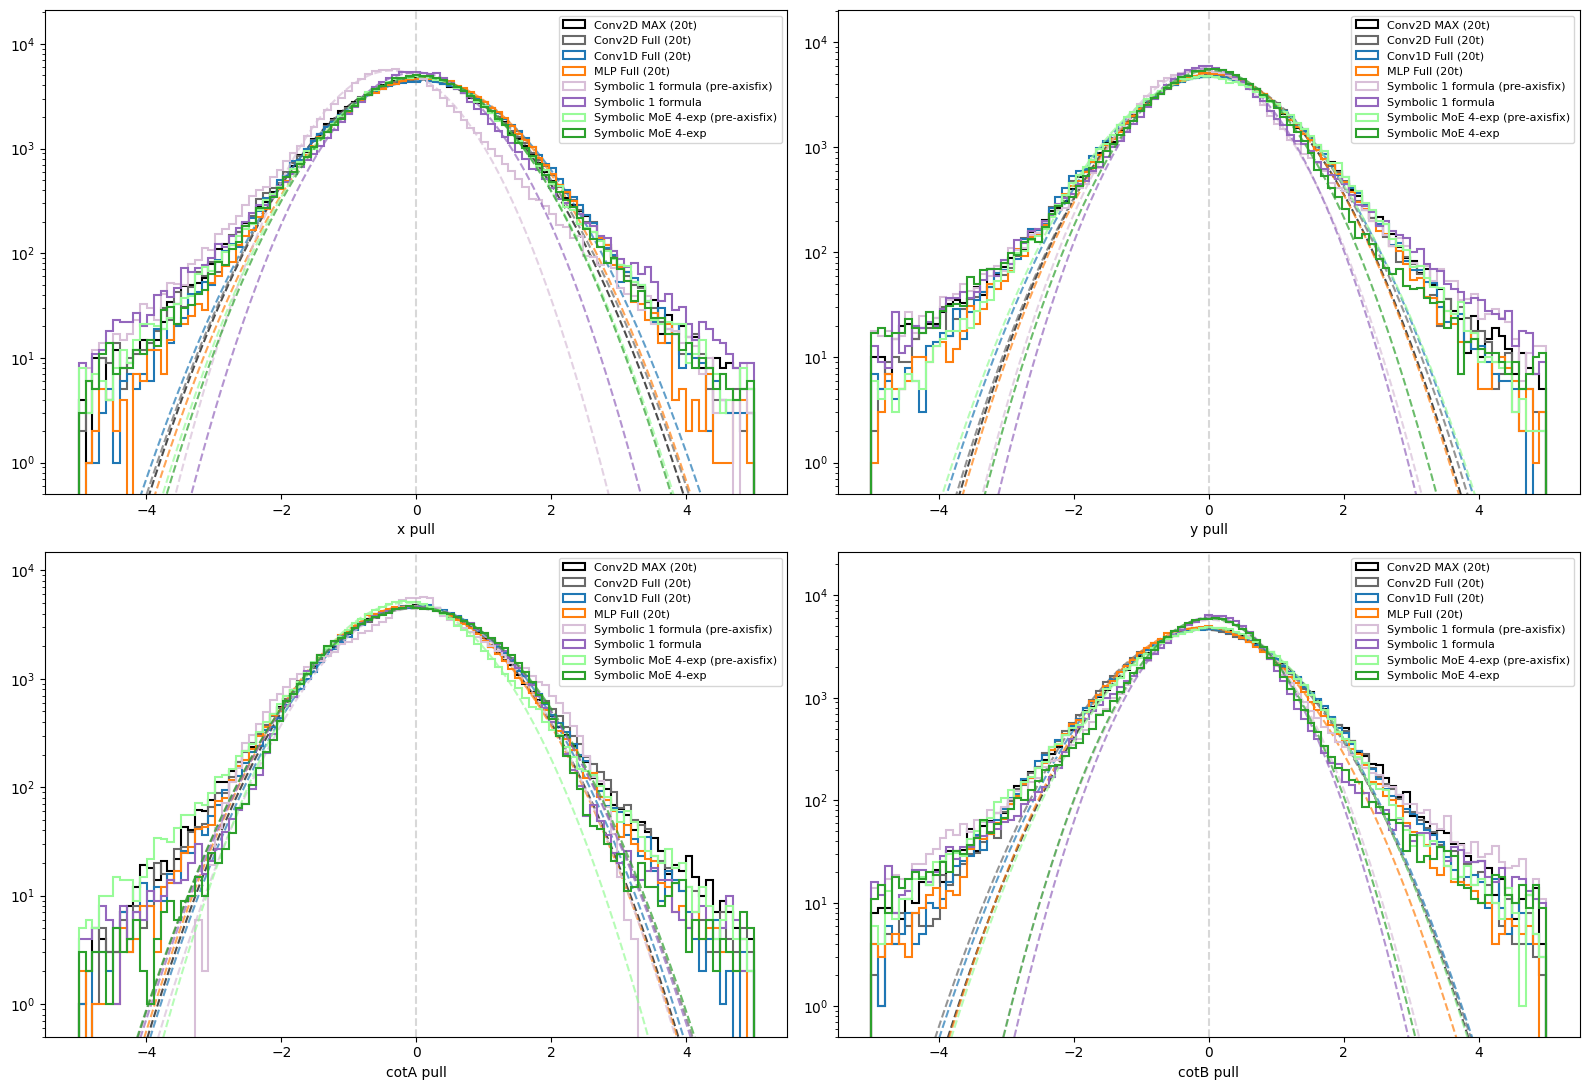

model                    var      pull mu  pull sigma   (sigma~1.0 = calibrated)
Conv2D MAX (20t)         x          0.001       0.926
Conv2D Full (20t)        x          0.022       0.941
Conv1D Full (20t)        x          0.069       0.973
MLP Full (20t)           x          0.097       0.928
Symbolic 1 formula (pre-axisfix) x         -0.359       0.743
Symbolic 1 formula       x         -0.003       0.773
Symbolic MoE 4-exp (pre-axisfix) x          0.027       0.883
Symbolic MoE 4-exp       x          0.039       0.872
Conv2D MAX (20t)         y          0.019       0.867
Conv2D Full (20t)        y          0.047       0.884
Conv1D Full (20t)        y          0.015       0.912
MLP Full (20t)           y          0.031       0.857
Symbolic 1 formula (pre-axisfix) y         -0.101       0.754
Symbolic 1 formula       y         -0.023       0.716
Symbolic MoE 4-exp (pre-axisfix) y         -0.003       0.923
Symbolic MoE 4-exp       y          0.029       0.776
Conv2D MAX (20t)       

In [6]:
#==============================================================================
# PULLS (only files with sigma columns) + Gaussian-fit table
#==============================================================================
sig_entries = [e for e in entries if e["has_sigma"]]
if sig_entries:
    fig, axes = plt.subplots(2, 2, figsize=figsize_pulls)
    pull_results = {}
    for var, name, ax in [("x", "x pull", axes[0, 0]), ("y", "y pull", axes[0, 1]),
                          ("cotA", "cotA pull", axes[1, 0]), ("cotB", "cotB pull", axes[1, 1])]:
        for e in sig_entries:
            if var == "cotA" and not e["has_alpha"]:
                continue
            df = e["df"]
            pull = (df[var + "true"].values - df[var].values) / (df["sigma" + var].values + 1e-12)
            h = ax.hist(pull, bins=np.linspace(-5, 5, 100), histtype="step",
                        label=e["label"], color=e["color"], linewidth=1.5)
            xd = h[1][:-1] + np.diff(h[1]) / 2
            try:
                pars, _ = curve_fit(gauss, xd, h[0], p0=[h[0].max(), 0, 1], maxfev=5000)
                ax.plot(np.linspace(-5, 5, 200), gauss(np.linspace(-5, 5, 200), *pars),
                        color=e["color"], ls="--", alpha=0.7)
                pull_results[(e["label"], var)] = dict(mu=pars[1], sigma=abs(pars[2]))
            except Exception:
                pull_results[(e["label"], var)] = dict(mu=np.nan, sigma=np.nan)
        ax.set_xlabel(name); ax.set_yscale("log")
        ax.axvline(0, alpha=0.3, ls="dashed", color="gray")
        ax.legend(fontsize=8); ax.set_ylim(0.5, None)
    plt.tight_layout()
    if output_dir:
        plt.savefig(os.path.join(output_dir, "pulls.png"), dpi=save_dpi, bbox_inches="tight")
    plt.show()

    print(f"{'model':<24s} {'var':<6s} {'pull mu':>9s} {'pull sigma':>11s}   (sigma~1.0 = calibrated)")
    for (lab, var), r in pull_results.items():
        print(f"{lab:<24s} {var:<6s} {r['mu']:9.3f} {r['sigma']:11.3f}")
else:
    print("no sigma-carrying files loaded -- pulls skipped")

In [7]:
#==============================================================================
# RESOLUTION TABLE: mean / std / I68 per variable (I68 is the paper metric)
#==============================================================================
rows = []
for e in entries:
    for var, unit in [("x", "um"), ("y", "um"), ("cotA", "deg"), ("cotB", "deg")]:
        if var == "cotA" and not e["has_alpha"]:
            continue
        t, p, _ = get_phys(e, var)
        r = t - p
        rows.append(dict(model=e["label"], var=var, unit=unit,
                         mean=np.mean(r), std=np.std(r), I68=i68(r), n=len(r)))
summ = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:8.4f}")
print(summ.to_string(index=False))
if output_dir:
    summ.to_csv(os.path.join(output_dir, "summary.csv"), index=False)

print("\nI68 (half-width of minimal 68% interval):")
print(summ.pivot(index="model", columns="var", values="I68").to_string())

                           model  var unit     mean      std      I68      n
                Conv2D MAX (20t)    x   um   0.0712   7.8196   5.2930 108222
                Conv2D MAX (20t)    y   um   0.0091   2.1246   1.2545 108222
                Conv2D MAX (20t) cotA  deg   0.1484   4.7435   1.2024 108222
                Conv2D MAX (20t) cotB  deg  -0.0595   2.6537   1.3796 108222
               Conv2D Full (20t)    x   um  -0.0433   6.6411   4.1449 108222
               Conv2D Full (20t)    y   um  -0.0088   1.9317   1.0045 108222
               Conv2D Full (20t) cotA  deg   0.0425   4.0495   1.0418 108222
               Conv2D Full (20t) cotB  deg   0.0080   2.4445   1.2002 108222
               Conv1D Full (20t)    x   um   0.3076   5.4163   4.2938 108222
               Conv1D Full (20t)    y   um  -0.0054   1.8457   1.0131 108222
               Conv1D Full (20t) cotA  deg  -0.0179   4.2978   0.9342 108222
               Conv1D Full (20t) cotB  deg  -0.0075   2.3380   0.9391 108222

In [8]:
1

1

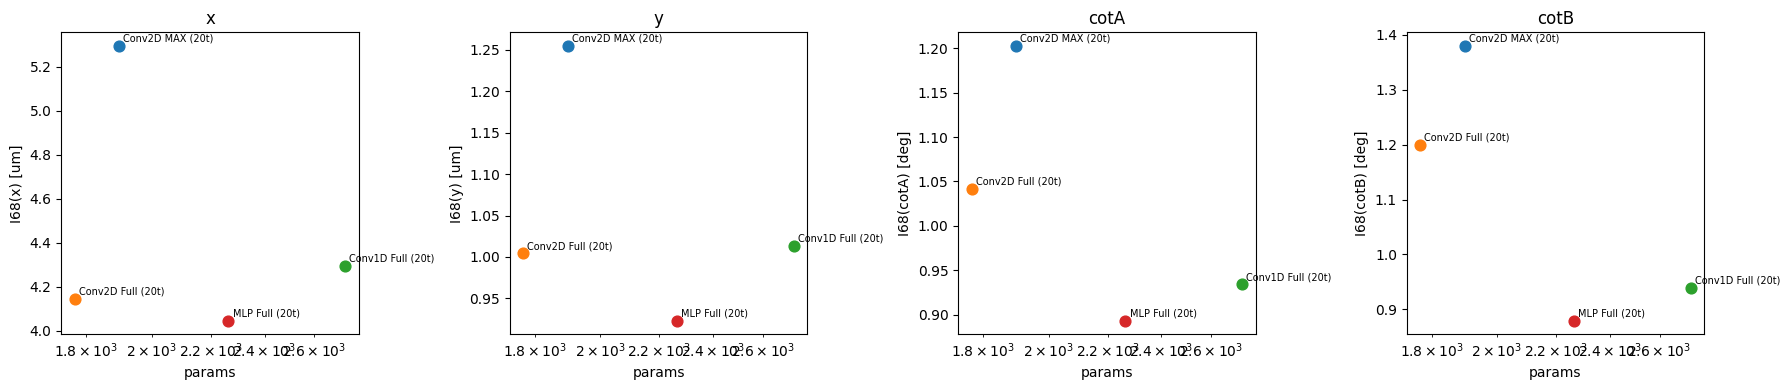

In [9]:
#==============================================================================
# PARAMS vs RESOLUTION scatter (bottom-left = better: fewer params, tighter I68)
#==============================================================================
sub = summ[summ["model"].isin(PARAM_COUNTS)]
if len(sub):
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))
    for ax, var in zip(axs, ["x", "y", "cotA", "cotB"]):
        d = sub[sub["var"] == var]
        for _, row in d.iterrows():
            ax.scatter(PARAM_COUNTS[row["model"]], row["I68"], s=60)
            ax.annotate(row["model"], (PARAM_COUNTS[row["model"]], row["I68"]),
                        fontsize=7, xytext=(3, 3), textcoords="offset points")
        ax.set_xscale("log"); ax.set_xlabel("params")
        ax.set_ylabel(f"I68({var}) [{d['unit'].iloc[0]}]"); ax.set_title(var)
    plt.tight_layout()
    if output_dir:
        plt.savefig(os.path.join(output_dir, "params_vs_resolution.png"), dpi=save_dpi, bbox_inches="tight")
    plt.show()
else:
    print("PARAM_COUNTS has no matching models -- add entries (incl. symbolic) to plot this")

---

# A. Axis fix — before vs after, isolated

Only the two symbolic families appear below: **before** = `symbolic_ablation_*` (ansatz v2 with the
`AxisFixExpert` wrapper — the wrapper un-swapped the two output *slots* but left the pitches, cluster
widths and sign observables inside the formula crossed), **after** = `symbolic_axisfix_*` (the fix
lives inside `ansatz.py` v3: cols = x @ 50 µm, rows = y @ 12.5 µm).

No baselines, no digitization arms on these plots — the point is one comparison at a time.

The cell prints two things:
- **slot-vs-truth correlations**, which is what catches a swap: a swapped x-slot has
  `corr(x_slot, x_true) ≈ 0` and `corr(x_slot, y_true) ≈ 0.9`. Both families pass this, because the
  wrapper already fixed the slots — so the residual differences below are the *internal* fix.
- **I68 before → after** per output, with the ratio.

slot-vs-truth correlations  (on-axis value should dominate; swapped slot -> ~0.00)
run                                 corr(x_slot,xt)  corr(x_slot,yt)  corr(y_slot,xt)  corr(y_slot,yt)
1 formula (N=1) pre-axisfix                   0.941            0.001            0.001            0.927
1 formula (N=1) axisfix                       0.941            0.001            0.001            0.927
MoE 4-exp (N=4) pre-axisfix                   0.989            0.002            0.001            0.941
MoE 4-exp (N=4) axisfix                       0.991            0.001            0.002            0.969


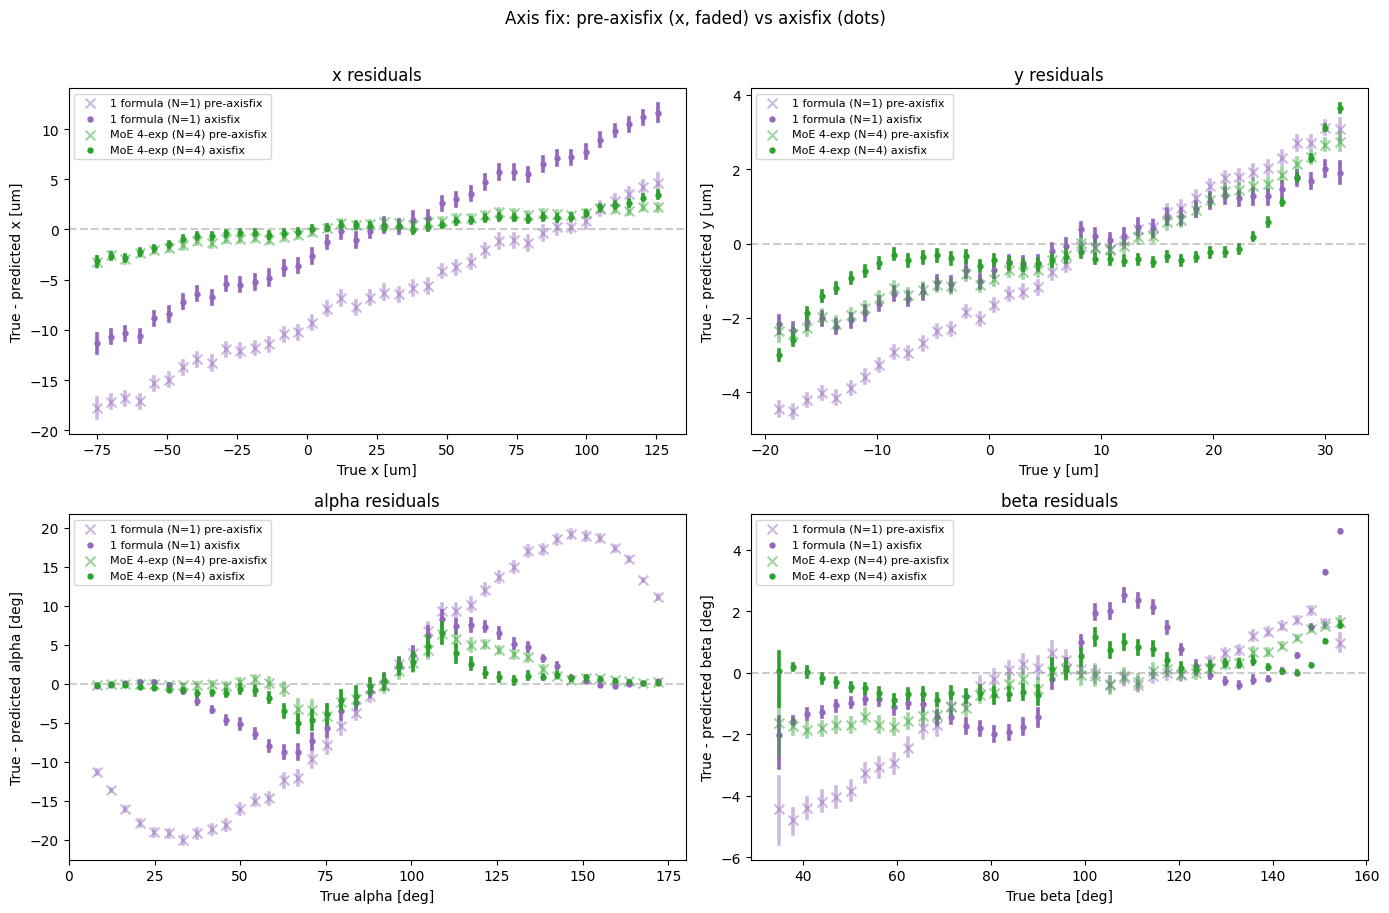


I68 (paper metric, half-width of the minimal 68% interval):
stage                        before    after  ratio_after/before better?
family          var   unit                                              
1 formula (N=1) alpha deg    20.306    1.744               0.086     yes
                beta  deg     4.584    2.563               0.559     yes
                x     um     15.559   15.606               1.003      no
                y     um      4.108    3.746               0.912     yes
MoE 4-exp (N=4) alpha deg     1.389    1.641               1.181      no
                beta  deg     3.628    2.212               0.610     yes
                x     um      6.850    6.515               0.951     yes
                y     um      3.520    2.503               0.711     yes


In [10]:
#==============================================================================
# A. AXIS FIX ONLY -- pre-axisfix vs axisfix. Nothing else on these plots.
#    Self-contained: runs on its own, does not need the cells above.
#==============================================================================
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SYM = "/depot/cms/private/users/kuang14/Smart_Pixel"
AXIS_PAIRS = [
    dict(name="1 formula (N=1)", color="tab:purple",
         before=f"{SYM}/symbolic_ablation_nexp1", after=f"{SYM}/symbolic_axisfix_nexp1"),
    dict(name="MoE 4-exp (N=4)", color="tab:green",
         before=f"{SYM}/symbolic_ablation_nexp4", after=f"{SYM}/symbolic_axisfix_nexp4"),
]
AXIS_OUT = None          # e.g. "./plots_axisfix" to save PNGs, or None

VARS = [("x", "x", "um"), ("y", "y", "um"), ("cotA", "alpha", "deg"), ("cotB", "beta", "deg")]

def _load(d):
    pq = sorted(glob.glob(os.path.join(d, "*_vars.parquet")))
    assert pq, f"no *_vars.parquet in {d}"
    ls = json.load(open(os.path.join(d, "labels_scale.json")))["labels_scale"]
    return pd.read_parquet(pq[0]), np.asarray(ls, float)

def _phys(df, ls, var):
    """(true, pred) in physical units -- um for x/y, DEGREES for the angles."""
    i = {"x": 0, "y": 1, "cotA": 2, "cotB": 3}[var]
    if var in ("x", "y"):
        return df[var + "true"].values * ls[i], df[var].values * ls[i]
    deg = lambda c: np.degrees(np.arctan2(1.0, np.asarray(c, float)))
    return deg(df[var + "true"].values * ls[i]), deg(df[var].values * ls[i])

def _i68(r):
    r = np.sort(np.asarray(r)[np.isfinite(r)])
    n = len(r); k = int(np.ceil(0.68 * n))
    return (r[-1] - r[0]) / 2.0 if k >= n else (r[k:] - r[:n - k]).min() / 2.0

# ---- load ----
runs = []
for p in AXIS_PAIRS:
    for stage, key, ls_style in [("before", "before", "--"), ("after", "after", "-")]:
        if not os.path.isdir(p[key]):
            print("MISSING (skipped):", p[key]); continue
        df, ls = _load(p[key])
        runs.append(dict(family=p["name"], stage=stage, df=df, ls=ls, color=p["color"],
                         lstyle=ls_style, dir=p[key],
                         label=f"{p['name']} {'pre-axisfix' if stage == 'before' else 'axisfix'}"))
assert runs, "nothing loaded"

# ---- (1) slot-vs-truth correlation: the diagnostic that catches a swap ----
print("slot-vs-truth correlations  (on-axis value should dominate; swapped slot -> ~0.00)")
print(f"{'run':<34s}{'corr(x_slot,xt)':>17s}{'corr(x_slot,yt)':>17s}"
      f"{'corr(y_slot,xt)':>17s}{'corr(y_slot,yt)':>17s}")
for r in runs:
    d = r["df"]
    c = lambda a, b: np.corrcoef(d[a].values, d[b].values)[0, 1]
    print(f"{r['label']:<34s}{c('x','xtrue'):>17.3f}{c('x','ytrue'):>17.3f}"
          f"{c('y','xtrue'):>17.3f}{c('y','ytrue'):>17.3f}")

# ---- (2) residual panels, before (dashed/open) vs after (solid) ----
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for (var, nm, unit), ax in zip(VARS, axes.ravel()):
    for r in runs:
        t, p = _phys(r["df"], r["ls"], var)
        sns.regplot(x=t, y=t - p, x_bins=np.linspace(t.min(), t.max(), 40), fit_reg=None,
                    marker="." if r["stage"] == "after" else "x", ax=ax, color=r["color"],
                    scatter_kws=dict(alpha=1.0 if r["stage"] == "after" else 0.45),
                    label=r["label"])
    ax.axhline(0, alpha=0.4, ls="dashed", color="gray")
    ax.set_xlabel(f"True {nm} [{unit}]"); ax.set_ylabel(f"True - predicted {nm} [{unit}]")
    ax.set_title(f"{nm} residuals"); ax.legend(fontsize=8)
fig.suptitle("Axis fix: pre-axisfix (x, faded) vs axisfix (dots)", y=1.01)
plt.tight_layout()
if AXIS_OUT:
    os.makedirs(AXIS_OUT, exist_ok=True)
    plt.savefig(os.path.join(AXIS_OUT, "axisfix_residuals.png"), dpi=300, bbox_inches="tight")
plt.show()

# ---- (3) I68 before -> after ----
rows = []
for r in runs:
    for var, nm, unit in VARS:
        t, p = _phys(r["df"], r["ls"], var)
        rows.append(dict(family=r["family"], stage=r["stage"], var=nm, unit=unit,
                         I68=_i68(t - p)))
tab = pd.DataFrame(rows).pivot_table(index=["family", "var", "unit"], columns="stage", values="I68")
tab = tab.reindex(columns=["before", "after"])
tab["ratio_after/before"] = tab["after"] / tab["before"]
tab["better?"] = np.where(tab["ratio_after/before"] < 1, "yes", "no")
print("\nI68 (paper metric, half-width of the minimal 68% interval):")
print(tab.to_string(float_format=lambda v: f"{v:8.3f}"))
if AXIS_OUT:
    tab.to_csv(os.path.join(AXIS_OUT, "axisfix_i68.csv"))


---

# B. Input digitization — soft quantization with **learned** thresholds

The on-sensor ADC is **2-bit**. Analog / 3-bit / 4-bit are reference points that price what
quantization costs; they are never candidate designs. At 2 bits only **three numbers** exist —
`T0, T1, T2` — and they *are* the ADC design. This section reads every `digi_*` run on disk and
compares those three numbers, plus what they cost in resolution and in sign accuracy.

### What "soft digitization" means (arXiv:2602.15946 Sec. IV)

Hard quantization has zero gradient a.e., so the thresholds cannot be trained. The paper replaces the
step function with a sum of logistic sigmoids on the **backward** pass only (hard quantize always on
the forward pass — an STE):

| | |
|---|---|
| positive bin widths | `Δᵢ = ln(1 + e^θᵢ)` (Eq. 2) — θ unconstrained, Δ > 0 |
| thresholds by cumulative sum | `Tⱼ = T_min + Σ_{k≤j} Δₖ` (Eq. 3) — monotone *by construction*, so learning can never reorder them |
| soft surrogate | `D_soft(x) = Σⱼ σ( k·(Tⱼ − x)/τⱼ )` (Eq. 4) |
| local scale | `τⱼ = (Δⱼ + Δⱼ₊₁)/2` (Eq. 5) — each edge is soft on the scale of its *own* bin, so a wide top bin and a narrow bottom bin both get usable gradient |
| temperature | `k: 1 → 67`, cosine-annealed (Sec. IV A) — soft enough to move at the start, a hard step by the end |
| noise | `Q_in = Q_sim + ε`, `ε ~ N(0, σ_noise)`, `σ_noise = 80 e⁻` (Eq. 6), added to the **analog** charge, digitized after |
| levels | the bin index `0..3` (Eq. 1) |

Consequences, and why the plots below are laid out as they are:

- `k` matters as much as the learning rate. Large fixed `k` → step-like sigmoids → the thresholds get
  essentially no gradient, so a "trainable threshold" run with `k = 50` learns nothing. `DigitizeLayer`
  raises on that combination; the trainable arms use `k_init = 1` plus `AnnealK`.
- `T_min` is a hard floor on the learned `T0` (it is where the cumulative sum starts). With
  `T_min = 240 e⁻` the optimizer cannot walk `T0` down into the noise — which is exactly what the
  superseded occupancy-derived placement did (`T0 = 100 e⁻` = 1.25 σ_noise).
- Thresholds are learned in **phase 1 only** and then frozen, so phases 2–3 fit the physics and the
  σ's against the fixed ADC that would actually ship.

### Read the table this way

- `paper_comparable` = 2-bit, published thresholds, `code` levels. Anything else is a reference point
  or costs chip area (`midpoint` assumes a 4-entry code→charge LUT the baselines do not have).
- `T_final − published` is the deliverable of the trainable arms: how far end-to-end training moves
  the ADC away from the published `248 / 668 / 1663 e⁻` (± 6 / 8 / 39).
- **Sign accuracy is reported per arm.** The sign gate reads the between-slice centroid drift `Tx, Ty`
  — a small differential quantity, and the first thing coarse quantization or noise destroys. Expect
  it to move before the position resolutions do.

published 2-bit thresholds: [ 248.  668. 1663.] +- [ 6.  8. 39.] e-  | sigma_noise=80 e-, 5 sigma=400 e-
source: arXiv:2602.15946 Sec. IV / Fig. 3 (Max transformer, SoftQuantize) 

no parquet (skipped): digi_2bit_paper_code_noise80_nexp1
                         run   bits  N   scheme   levels  train_T paper_cmp  noise_tr  noise_te                                                      T_init [e-]                                                     T_final [e-]     T-pub [e-]   I68_x   I68_y   I68_a   I68_b  sign_a  sign_b  pull_x  params
2bit_lowfirst_midpoint_nexp1      2  1 lowfirst midpoint    False     False     0.000     0.000                                                     100/240/1295                                                     100/240/1295 -148/-428/-368  20.080   5.048   1.829   2.976   0.973   0.969   1.006     376
3bit_lowfirst_midpoint_nexp1      3  1 lowfirst midpoint    False     False     0.000     0.000                                    100/146/208/350/792/1

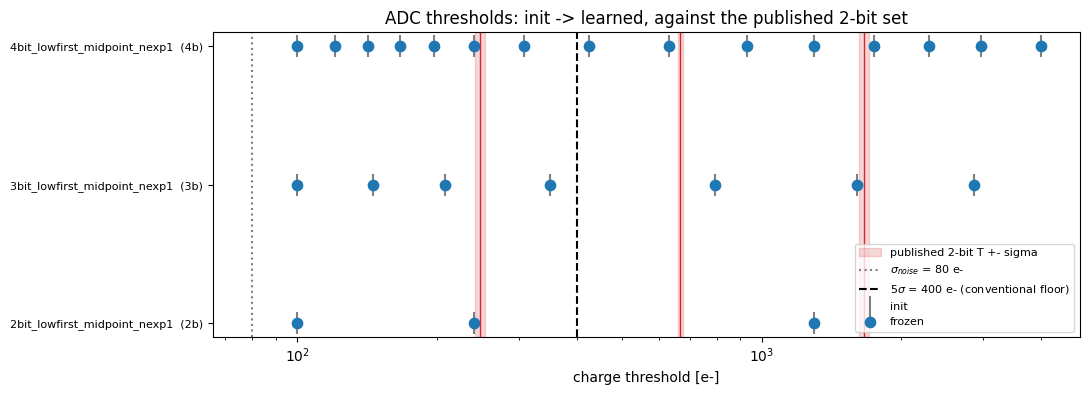

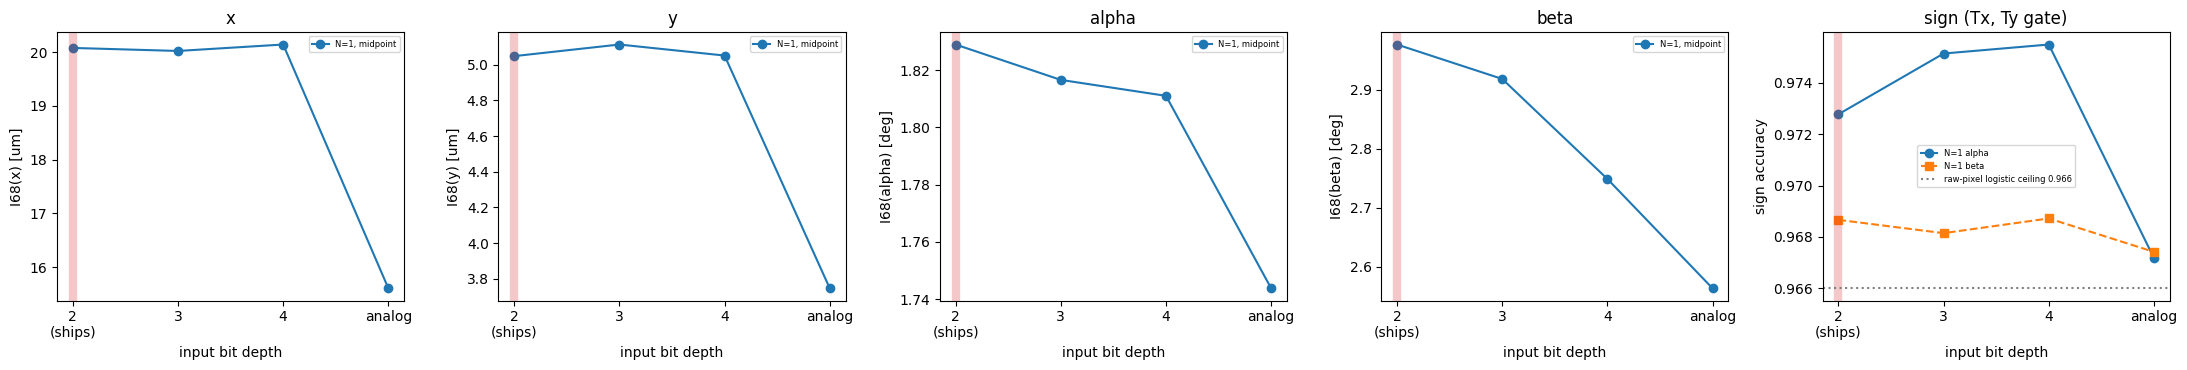


no trainable-threshold run on disk yet (summary['threshold_trace'] empty) -- run the TRAINABLE_THR=True arm of train_digitization_ablation.ipynb

provenance check:
  2bit_lowfirst_midpoint_nexp1           2-bit lowfirst/midpoint  NOT paper-comparable; midpoint levels = extra on-chip LUT; T0=100 e- = 1.25 sigma_noise -- digitizes noise
  3bit_lowfirst_midpoint_nexp1           3-bit lowfirst/midpoint  NOT paper-comparable; midpoint levels = extra on-chip LUT; T0=100 e- = 1.25 sigma_noise -- digitizes noise
  4bit_lowfirst_midpoint_nexp1           4-bit lowfirst/midpoint  NOT paper-comparable; midpoint levels = extra on-chip LUT; T0=100 e- = 1.25 sigma_noise -- digitizes noise
  axisfix N=1 (analog ref)               analog reference


In [11]:
#==============================================================================
# B. DIGITIZATION STUDY -- discovers every digi_* run, compares thresholds
#    (published vs learned), I68, pulls and sign accuracy.
#    Self-contained: runs on its own, does not need the cells above. No TF needed.
#==============================================================================
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SYM       = "/depot/cms/private/users/kuang14/Smart_Pixel"
HELP      = f"{SYM}/smart-pixels-digitization/two_bit_optimization_helpers"
DIGI_GLOB = f"{SYM}/digi_*_nexp*"        # every digitization arm on disk
EXTRA_REF = {                            # non-digi runs to carry as the analog reference
    "axisfix N=1 (analog ref)": f"{SYM}/symbolic_axisfix_nexp1",
}
DIGI_OUT  = None                         # e.g. "./plots_digi", or None

# Published constants. Single source of truth is symbolic/digitize.py -- read out of
# the file rather than imported, so this notebook never has to load TensorFlow.
_keys = ("SIGMA_NOISE_E", "FIVE_SIGMA_E", "PAPER_THRESHOLDS_2BIT",
         "PAPER_THRESHOLD_STD_2BIT", "PAPER_REF")
_ns = {}
exec("\n".join(l for l in open(f"{HELP}/symbolic/digitize.py")
               if l.split("=")[0].strip() in _keys), _ns)
SIGMA_NOISE_E, FIVE_SIGMA_E = _ns["SIGMA_NOISE_E"], _ns["FIVE_SIGMA_E"]
PAPER_T     = np.asarray(_ns["PAPER_THRESHOLDS_2BIT"], float)
PAPER_T_STD = np.asarray(_ns["PAPER_THRESHOLD_STD_2BIT"], float)
print("published 2-bit thresholds:", PAPER_T, "+-", PAPER_T_STD, "e-  |",
      f"sigma_noise={SIGMA_NOISE_E:.0f} e-, 5 sigma={FIVE_SIGMA_E:.0f} e-")
print("source:", _ns["PAPER_REF"], "\n")

VARS = [("x", "x", "um"), ("y", "y", "um"), ("cotA", "alpha", "deg"), ("cotB", "beta", "deg")]

def _i68(r):
    r = np.sort(np.asarray(r)[np.isfinite(r)])
    n = len(r); k = int(np.ceil(0.68 * n))
    return (r[-1] - r[0]) / 2.0 if k >= n else (r[k:] - r[:n - k]).min() / 2.0

def _phys(df, ls, var):
    i = {"x": 0, "y": 1, "cotA": 2, "cotB": 3}[var]
    if var in ("x", "y"):
        t, p = df[var + "true"].values * ls[i], df[var].values * ls[i]
        return t, p, df["sigma" + var].values * ls[i]
    deg = lambda c: np.degrees(np.arctan2(1.0, np.asarray(c, float)))
    t, p = deg(df[var + "true"].values * ls[i]), deg(df[var].values * ls[i])
    s = df["sigma" + var].values
    sg = 0.5 * (np.abs(deg((df[var].values + s) * ls[i]) - p) +
                np.abs(deg((df[var].values - s) * ls[i]) - p))
    return t, p, sg

def _read_run(d, label=None):
    """One run directory -> dict of quantizer config + metrics. Tolerates the older
    summary.json layout (flat 'thresholds'/'thr_scheme') and the current describe() one."""
    pq = sorted(glob.glob(os.path.join(d, "*_vars.parquet")))
    if not pq:
        return None
    df = pd.read_parquet(pq[0])
    ls = np.asarray(json.load(open(os.path.join(d, "labels_scale.json")))["labels_scale"], float)
    sj = os.path.join(d, "summary.json")
    s  = json.load(open(sj)) if os.path.exists(sj) else {}
    g  = s.get("digitization") or {}
    prov = g.get("threshold_provenance") or {}
    noise = s.get("noise") or {}

    thr_i = g.get("thresholds_initial_e", g.get("thresholds"))
    thr_f = g.get("thresholds_final_e",   g.get("thresholds"))
    r = dict(
        dir=os.path.basename(d), label=label or os.path.basename(d).replace("digi_", ""),
        n_bits=g.get("n_bits"),
        scheme=prov.get("scheme", g.get("thr_scheme", "-" if g.get("n_bits") is None else "?")),
        level_mode=g.get("level_mode", g.get("level_mode_requested", "-")),
        trainable_thr=bool(g.get("trainable_thresholds", False)),
        T_init=None if thr_i is None else np.asarray(thr_i, float),
        T_final=None if thr_f is None else np.asarray(thr_f, float),
        k_init=g.get("initial_k"), k_final=g.get("final_k"),
        T_min=g.get("threshold_offset_e", g.get("offset")),
        train_noise=noise.get("train_sigma_e", 0.0), test_noise=noise.get("test_sigma_e", 0.0),
        n_experts=s.get("n_experts"), params=s.get("total_params"),
        trace=s.get("threshold_trace"), df=df, ls=ls,
    )
    r["paper_comparable"] = bool(r["n_bits"] == 2 and r["scheme"] == "paper"
                                and r["level_mode"] == "code")
    # metrics recomputed from the parquet, so runs written before summary["metrics"] existed
    # are still comparable, and every number here uses this notebook's definitions
    for var, nm, unit in VARS:
        t, p, sg = _phys(df, ls, var)
        res = t - p
        r[f"I68_{nm}"] = _i68(res)
        r[f"pull_{nm}"] = float((res / (sg + 1e-12)).std())
        if var.startswith("cot"):
            r[f"sign_{nm}"] = float((np.sign(df[var].values) ==
                                     np.sign(df[var + "true"].values)).mean())
    return r

runs = []
for d in sorted(glob.glob(DIGI_GLOB)) + [v for v in EXTRA_REF.values()]:
    lab = next((k for k, v in EXTRA_REF.items() if v == d), None)
    if not os.path.isdir(d):
        print("MISSING (skipped):", d); continue
    r = _read_run(d, lab)
    if r is None:
        print("no parquet (skipped):", os.path.basename(d)); continue
    runs.append(r)
assert runs, f"no runs matched {DIGI_GLOB} -- has any digitization arm been trained yet?"

# ---- table ----
def _fmt(a):
    return "-" if a is None else "/".join(f"{v:.0f}" for v in np.atleast_1d(a))

tab = pd.DataFrame([{
    "run": r["label"], "bits": "analog" if r["n_bits"] is None else r["n_bits"],
    "N": r["n_experts"], "scheme": r["scheme"], "levels": r["level_mode"],
    "train_T": r["trainable_thr"],
    "paper_cmp": "-" if r["n_bits"] is None else r["paper_comparable"],
    "noise_tr": r["train_noise"], "noise_te": r["test_noise"],
    "T_init [e-]": _fmt(r["T_init"]), "T_final [e-]": _fmt(r["T_final"]),
    "T-pub [e-]": (_fmt(r["T_final"] - PAPER_T) if (r["n_bits"] == 2 and r["T_final"] is not None)
                   else "-"),
    "I68_x": r["I68_x"], "I68_y": r["I68_y"], "I68_a": r["I68_alpha"], "I68_b": r["I68_beta"],
    "sign_a": r["sign_alpha"], "sign_b": r["sign_beta"],
    "pull_x": r["pull_x"], "params": r["params"],
} for r in runs]).sort_values(["bits", "run"], key=lambda c: c.astype(str))
print(tab.to_string(index=False, float_format=lambda v: f"{v:7.3f}"))

# cost of 2-bit against the analog reference (paper quotes 5-10% for its own models)
_ana = [r for r in runs if r["n_bits"] is None]
_two = [r for r in runs if r["n_bits"] == 2]
if _ana and _two:
    a = _ana[0]
    print(f"\ncost of 2-bit vs '{a['label']}'  (paper quotes 5-10% for its models):")
    for r in _two:
        d = "  ".join(f"{nm}:{100*(r[f'I68_{nm}']/a[f'I68_{nm}'] - 1):+6.1f}%"
                      for _, nm, _ in VARS)
        print(f"  {r['label']:<38s}{d}")

# ---- threshold map: where every arm put its three (or 2^n-1) edges ----
qruns = [r for r in runs if r["T_final"] is not None]
if qruns:
    fig, ax = plt.subplots(figsize=(11, 0.55 * len(qruns) + 2.4))
    for j, (t, sd) in enumerate(zip(PAPER_T, PAPER_T_STD)):
        ax.axvspan(t - sd, t + sd, color="tab:red", alpha=0.18,
                   label="published 2-bit T +- sigma" if j == 0 else None)
        ax.axvline(t, color="tab:red", lw=1)
    ax.axvline(SIGMA_NOISE_E, color="gray", ls=":", label=r"$\sigma_{noise}$ = 80 e-")
    ax.axvline(FIVE_SIGMA_E, color="k", ls="--", label=r"5$\sigma$ = 400 e- (conventional floor)")
    for i, r in enumerate(qruns):
        ax.scatter(r["T_init"], [i] * len(r["T_init"]), marker="|", s=260, color="gray",
                   label="init" if i == 0 else None)
        ax.scatter(r["T_final"], [i] * len(r["T_final"]), marker="o", s=55,
                   color="darkred" if r["trainable_thr"] else "tab:blue",
                   label=("learned (trainable)" if r["trainable_thr"] else "frozen")
                         if i == 0 else None)
        for ti, tf in zip(r["T_init"], r["T_final"]):
            if abs(tf - ti) > 1:
                ax.annotate("", xy=(tf, i), xytext=(ti, i),
                            arrowprops=dict(arrowstyle="->", color="darkred", lw=1))
    ax.set_yticks(range(len(qruns)))
    ax.set_yticklabels([f"{r['label']}  ({r['n_bits']}b)" for r in qruns], fontsize=8)
    ax.set_xscale("log"); ax.set_xlabel("charge threshold [e-]")
    ax.set_title("ADC thresholds: init -> learned, against the published 2-bit set")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    if DIGI_OUT:
        os.makedirs(DIGI_OUT, exist_ok=True)
        plt.savefig(os.path.join(DIGI_OUT, "digi_thresholds.png"), dpi=300, bbox_inches="tight")
    plt.show()

# ---- I68 and sign accuracy vs bit depth (analog plotted to the right of 4-bit) ----
BIT_X = {None: 5, 2: 2, 3: 3, 4: 4}
# A family is one design (N, level mode, trainable-T, train noise) swept over bit depth.
# The analog reference joins every family with its N, so each line ends at "analog" and the
# cost of quantization is read straight off the plot.
fams = {}
for r in runs:
    if r["n_bits"] is None:
        continue
    fams.setdefault((r["n_experts"], r["level_mode"], r["trainable_thr"],
                     r["train_noise"]), []).append(r)
for key in list(fams):
    fams[key] = fams[key] + [r for r in runs
                             if r["n_bits"] is None and r["n_experts"] == key[0]]
fig, axes = plt.subplots(1, 5, figsize=(22, 3.8))
for ax, (var, nm, unit) in zip(axes, VARS):
    for key, rs in fams.items():
        rs = sorted(rs, key=lambda r: BIT_X[r["n_bits"]])
        lab = f"N={key[0]}, {key[1]}" + (", train-T" if key[2] else "") + \
              (f", noise {key[3]:.0f}e-" if key[3] else "")
        ax.plot([BIT_X[r["n_bits"]] for r in rs], [r[f"I68_{nm}"] for r in rs],
                "o-" if not key[2] else "s--", ms=6, label=lab)
    ax.axvline(2, color="tab:red", alpha=0.25, lw=6)
    ax.set_xticks([2, 3, 4, 5]); ax.set_xticklabels(["2\n(ships)", "3", "4", "analog"])
    ax.set_xlabel("input bit depth"); ax.set_ylabel(f"I68({nm}) [{unit}]"); ax.set_title(nm)
ax = axes[4]
for key, rs in fams.items():
    rs = sorted(rs, key=lambda r: BIT_X[r["n_bits"]])
    for nm, mk in [("alpha", "o-"), ("beta", "s--")]:
        ax.plot([BIT_X[r["n_bits"]] for r in rs], [r[f"sign_{nm}"] for r in rs], mk, ms=6,
                label=f"N={key[0]} {nm}" + (", train-T" if key[2] else ""))
ax.axvline(2, color="tab:red", alpha=0.25, lw=6)
ax.axhline(0.966, color="gray", ls=":", label="raw-pixel logistic ceiling 0.966")
ax.set_xticks([2, 3, 4, 5]); ax.set_xticklabels(["2\n(ships)", "3", "4", "analog"])
ax.set_xlabel("input bit depth"); ax.set_ylabel("sign accuracy"); ax.set_title("sign (Tx, Ty gate)")
for a in axes:
    a.legend(fontsize=6)
plt.tight_layout()
if DIGI_OUT:
    plt.savefig(os.path.join(DIGI_OUT, "digi_i68_vs_bits.png"), dpi=300, bbox_inches="tight")
plt.show()

# ---- threshold trajectory during phase 1, for the trainable arms ----
traced = [r for r in runs if r["trace"]]
if traced:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for r in traced:
        ep = [h["epoch"] for h in r["trace"]]
        T  = np.asarray([h["thresholds_e"] for h in r["trace"]], float)
        for j in range(T.shape[1]):
            axes[0].plot(ep, T[:, j], label=f"{r['label']} T{j}")
        axes[1].plot(ep, [h["k"] for h in r["trace"]], label=r["label"])
    for j, (t, sd) in enumerate(zip(PAPER_T, PAPER_T_STD)):
        axes[0].axhline(t, color="tab:red", ls="--", lw=1,
                        label="published" if j == 0 else None)
        axes[0].fill_between([min(ep), max(ep)], t - sd, t + sd, color="tab:red", alpha=0.15)
    axes[0].set_xlabel("phase-1 epoch"); axes[0].set_ylabel("threshold [e-]")
    axes[0].set_title("learned thresholds (frozen at end of phase 1)"); axes[0].legend(fontsize=7)
    axes[1].set_xlabel("phase-1 epoch"); axes[1].set_ylabel("k")
    axes[1].set_title("SoftQuantize temperature, cosine 1 -> 67"); axes[1].legend(fontsize=7)
    plt.tight_layout()
    if DIGI_OUT:
        plt.savefig(os.path.join(DIGI_OUT, "digi_threshold_trace.png"), dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("\nno trainable-threshold run on disk yet (summary['threshold_trace'] empty) -- "
          "run the TRAINABLE_THR=True arm of train_digitization_ablation.ipynb")

# ---- provenance / comparability flags ----
print("\nprovenance check:")
for r in runs:
    if r["n_bits"] is None:
        print(f"  {r['label']:<38s} analog reference"); continue
    t0 = r["T_final"][0]
    flags = []
    if not r["paper_comparable"]:
        flags.append("NOT paper-comparable")
    if r["level_mode"] == "midpoint":
        flags.append("midpoint levels = extra on-chip LUT")
    if t0 < 3 * SIGMA_NOISE_E:
        flags.append(f"T0={t0:.0f} e- = {t0/SIGMA_NOISE_E:.2f} sigma_noise -- digitizes noise")
    if r["trainable_thr"] and r["k_init"] and r["k_init"] > 5:
        flags.append(f"trainable T with k_init={r['k_init']} -- thresholds got no gradient")
    print(f"  {r['label']:<38s} {r['n_bits']}-bit {r['scheme']}/{r['level_mode']}"
          f"  {'; '.join(flags) if flags else 'OK'}")
if DIGI_OUT:
    tab.to_csv(os.path.join(DIGI_OUT, "digi_summary.csv"), index=False)


---

# C. Input noise — resolution and sign vs sigma_noise

Arms from `train_noise_ablation.ipynb`. `Q_in = Q_sim + eps`, `eps ~ N(0, sigma)` on the **analog**
charge (Eq. 6), digitized after. Nominal sigma = **80 e-** — the Cadence/Spectre number, marked on
every panel.

**Lines only ever join arms with an identical quantizer** — same bit depth, same threshold scheme,
same level mode. Connecting a paper-threshold point to a `lowfirst/midpoint` point would draw a
"noise trend" out of two different ADCs. An unconnected single marker means that configuration has
only one sigma so far: that is information, not a bug — it tells you which arm is missing.

**Sign accuracy is the panel to read first.** The gate reads the between-slice centroid drift
`Tx, Ty` — two nearly equal numbers subtracted — so it degrades before the position resolutions do.

**Mismatch arms** (`summary.json["noise"]["train_test_mismatch"]`) are drawn as open markers at their
*test* sigma and listed in their own table. They separate "the model is robust to noise" from "the
model was trained on noise": a train-clean/test-80 arm falling well below the train-80/test-80 arm
means the robustness was learned, not inherent.


In [ ]:
#==============================================================================
# C. NOISE STUDY -- I68 and sign accuracy vs sigma_noise, at fixed quantizer.
#    Self-contained: runs on its own, does not need the cells above.
#==============================================================================
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SYM        = "/depot/cms/private/users/kuang14/Smart_Pixel"
NOISE_GLOB = f"{SYM}/digi_*_nexp*"
NOISE_REF  = {"axisfix N=1": f"{SYM}/symbolic_axisfix_nexp1"}   # clean analog reference
SIGMA_NOMINAL = 80.0        # e-, arXiv:2602.15946 Sec. IV B
NOISE_OUT  = None

VARS = [("x", "x", "um"), ("y", "y", "um"), ("cotA", "alpha", "deg"), ("cotB", "beta", "deg")]

def _i68(r):
    r = np.sort(np.asarray(r)[np.isfinite(r)])
    n = len(r); k = int(np.ceil(0.68 * n))
    return (r[-1] - r[0]) / 2.0 if k >= n else (r[k:] - r[:n - k]).min() / 2.0

def _load(d, label=None):
    pq = sorted(glob.glob(os.path.join(d, "*_vars.parquet")))
    if not pq:
        return None
    df = pd.read_parquet(pq[0])
    ls = np.asarray(json.load(open(os.path.join(d, "labels_scale.json")))["labels_scale"], float)
    sj = os.path.join(d, "summary.json")
    s  = json.load(open(sj)) if os.path.exists(sj) else {}
    g, nz = (s.get("digitization") or {}), (s.get("noise") or {})
    prov = g.get("threshold_provenance") or {}
    r = dict(label=label or os.path.basename(d).replace("digi_", ""),
             n_bits=g.get("n_bits"),
             # the quantizer identity: only arms agreeing on ALL of this may be joined
             quant=("analog" if g.get("n_bits") is None else
                    f"{g['n_bits']}bit/{prov.get('scheme', g.get('thr_scheme','?'))}/"
                    f"{g.get('level_mode','?')}"
                    + ("/trainT" if g.get("trainable_thresholds") else "")),
             n_experts=s.get("n_experts"),
             sig_tr=float(nz.get("train_sigma_e", 0.0) or 0.0),
             sig_te=float(nz.get("test_sigma_e", nz.get("train_sigma_e", 0.0)) or 0.0),
             mismatch=bool(nz.get("train_test_mismatch", False)))
    for var, nm, unit in VARS:
        i = {"x": 0, "y": 1, "cotA": 2, "cotB": 3}[var]
        if unit == "um":
            t, q = df[var + "true"].values * ls[i], df[var].values * ls[i]
        else:
            deg = lambda c: np.degrees(np.arctan2(1.0, np.asarray(c, float)))
            t, q = deg(df[var + "true"].values * ls[i]), deg(df[var].values * ls[i])
        r[f"I68_{nm}"] = _i68(t - q)
        if var.startswith("cot"):
            r[f"sign_{nm}"] = float((np.sign(df[var].values) ==
                                     np.sign(df[var + "true"].values)).mean())
    return r

runs_n = []
for d in sorted(glob.glob(NOISE_GLOB)) + list(NOISE_REF.values()):
    if not os.path.isdir(d):
        print("MISSING (skipped):", d); continue
    r = _load(d, next((k for k, v in NOISE_REF.items() if v == d), None))
    if r: runs_n.append(r)
assert runs_n, "nothing loaded"

matched  = [r for r in runs_n if not r["mismatch"]]
mismatch = [r for r in runs_n if r["mismatch"]]

tabn = pd.DataFrame([{
    "run": r["label"], "quantizer": r["quant"], "N": r["n_experts"],
    "sigma_train": r["sig_tr"], "sigma_test": r["sig_te"], "mismatch": r["mismatch"],
    "I68_x": r["I68_x"], "I68_y": r["I68_y"], "I68_a": r["I68_alpha"], "I68_b": r["I68_beta"],
    "sign_a": r["sign_alpha"], "sign_b": r["sign_beta"],
} for r in runs_n]).sort_values(["quantizer", "sigma_train", "sigma_test"])
print(tabn.to_string(index=False, float_format=lambda v: f"{v:7.3f}"))

# ---- panels: everything vs sigma, joined only within one quantizer ----
fams = {}
for r in matched:
    fams.setdefault((r["quant"], r["n_experts"]), []).append(r)
fig, axes = plt.subplots(1, 5, figsize=(22, 3.9))
for ax, (var, nm, unit) in zip(axes, VARS):
    for (q, N), rs in sorted(fams.items()):
        rs = sorted(rs, key=lambda r: r["sig_tr"])
        ax.plot([r["sig_tr"] for r in rs], [r[f"I68_{nm}"] for r in rs],
                "o-" if len(rs) > 1 else "o", ms=7, label=f"{q}, N={N}")
    for r in mismatch:      # open marker at the sigma it was TESTED at
        ax.plot(r["sig_te"], r[f"I68_{nm}"], "D", mfc="none", ms=8, color="k")
        ax.annotate(f"train {r['sig_tr']:.0f}", (r["sig_te"], r[f"I68_{nm}"]),
                    fontsize=6, xytext=(4, 4), textcoords="offset points")
    ax.axvline(SIGMA_NOMINAL, color="tab:red", alpha=0.3, lw=5)
    ax.set_xlabel(r"$\sigma_{noise}$ [e-]  (nominal 80)")
    ax.set_ylabel(f"I68({nm}) [{unit}]"); ax.set_title(nm)
ax = axes[4]
for (q, N), rs in sorted(fams.items()):
    rs = sorted(rs, key=lambda r: r["sig_tr"])
    for nm, mk in [("alpha", "o-"), ("beta", "s--")]:
        ax.plot([r["sig_tr"] for r in rs], [r[f"sign_{nm}"] for r in rs],
                mk if len(rs) > 1 else mk[0], ms=7, label=f"{q} {nm}")
for r in mismatch:
    ax.plot(r["sig_te"], r["sign_alpha"], "D", mfc="none", ms=8, color="k")
ax.axvline(SIGMA_NOMINAL, color="tab:red", alpha=0.3, lw=5)
ax.axhline(0.966, color="gray", ls=":", label="raw-pixel ceiling 0.966")
ax.set_xlabel(r"$\sigma_{noise}$ [e-]"); ax.set_ylabel("sign accuracy")
ax.set_title("sign (Tx, Ty gate) -- degrades first")
for a in axes:
    a.legend(fontsize=6)
plt.tight_layout()
if NOISE_OUT:
    os.makedirs(NOISE_OUT, exist_ok=True)
    plt.savefig(os.path.join(NOISE_OUT, "noise_vs_sigma.png"), dpi=300, bbox_inches="tight")
plt.show()

# ---- what the noise costs, at fixed quantizer (so it is noise alone, not quantization) ----
print("\ncost of noise AT FIXED QUANTIZER (needs a sigma=0 arm of the same quantizer):")
for (q, N), rs in sorted(fams.items()):
    base = [r for r in rs if r["sig_tr"] == 0]
    if not base:
        have = ", ".join(f"{r['sig_tr']:.0f}" for r in sorted(rs, key=lambda r: r["sig_tr"]))
        print(f"  {q}, N={N}: no clean arm -- have sigma = {have} e-. "
              f"Run this quantizer at NOISE_SIGMA=0 before quoting a noise cost.")
        continue
    b = base[0]
    for r in sorted(rs, key=lambda r: r["sig_tr"]):
        if r["sig_tr"] == 0: continue
        d = "  ".join(f"{nm}:{100*(r[f'I68_{nm}']/b[f'I68_{nm}'] - 1):+6.1f}%" for _, nm, _ in VARS)
        print(f"  {q}, N={N}, sigma={r['sig_tr']:.0f} e-: {d}"
              f"   sign {b['sign_alpha']:.3f}->{r['sign_alpha']:.3f} (a), "
              f"{b['sign_beta']:.3f}->{r['sign_beta']:.3f} (b)")

# ---- train/test mismatch arms ----
if mismatch:
    print("\ntrain/test mismatch arms (robust vs trained-on-noise):")
    for r in mismatch:
        peer = [m for m in matched if m["quant"] == r["quant"]
                and abs(m["sig_tr"] - r["sig_te"]) < 1e-6]
        tag = (f"vs trained-at-{r['sig_te']:.0f} peer: "
               + "  ".join(f"{nm}:{100*(r[f'I68_{nm}']/peer[0][f'I68_{nm}'] - 1):+6.1f}%"
                           for _, nm, _ in VARS)) if peer else "no matched peer to compare against"
        print(f"  {r['label']}: train {r['sig_tr']:.0f} -> test {r['sig_te']:.0f} e-  |  {tag}")
else:
    print("\nno train/test mismatch arm yet -- run NOISE_SIGMA=0 with TEST_NOISE_SIGMA=80 "
          "(and the reverse) to separate robustness from noise-aware training")
if NOISE_OUT:
    tabn.to_csv(os.path.join(NOISE_OUT, "noise_summary.csv"), index=False)
